# Evaluación de los modelos de Machine Learning
## Detección de cianobacteria en los lagos Atitlán y Amatitlán

Este notebook evalúa los tres modelos entrenados en el notebook 04 sobre el **mismo conjunto de prueba** (30% del total), garantizando comparaciones justas. Se calculan Accuracy, Precision, Recall, F1-score, ROC-AUC y las matrices de confusión, y se analiza cuál modelo es más adecuado desde el punto de vista ambiental.

**Contenido:**
1. Carga de modelos y datos de prueba
2. Métricas de evaluación para cada modelo (5.1)
3. Comparación entre modelos (5.2)
4. Análisis ambiental de los errores: ¿qué error importa más? (5.3)

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import warnings
warnings.filterwarnings('ignore')

import joblib
from pathlib import Path

from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, roc_curve, precision_recall_curve,
    average_precision_score,
    f1_score, precision_score, recall_score, accuracy_score,
    ConfusionMatrixDisplay
)

np.random.seed(42)

## 1. Carga de modelos y datos de prueba

In [2]:
mejor_lr  = joblib.load('./modelos/modelo_lr.pkl')
mejor_rf  = joblib.load('./modelos/modelo_rf.pkl')
mejor_xgb = joblib.load('./modelos/modelo_xgb.pkl')

X_test = pd.read_parquet('./data/X_test.parquet')
y_test = pd.read_parquet('./data/y_test.parquet').squeeze()

print(f'Conjunto de prueba: {len(X_test):,} observaciones')
print(f'Clase 1 en prueba: {y_test.sum():,} ({100*y_test.mean():.2f}%)')

modelos = {
    'Regresión Logística': mejor_lr,
    'Random Forest': mejor_rf,
    'XGBoost': mejor_xgb
}

Conjunto de prueba: 4,054,414 observaciones
Clase 1 en prueba: 90,327 (2.23%)


## 2. Generación de predicciones

Se generan tanto las **etiquetas predichas** (para métricas basadas en umbral = 0.5) como las **probabilidades** (para AUC-ROC, curva ROC, curva PR).

In [3]:
predicciones = {}
for nombre, modelo in modelos.items():
    y_pred = modelo.predict(X_test)
    y_prob = modelo.predict_proba(X_test)[:, 1]
    predicciones[nombre] = {'y_pred': y_pred, 'y_prob': y_prob}
    print(f'{nombre}: {y_pred.sum():,} píxeles predichos como clase 1 ({100*y_pred.mean():.2f}%)')

Regresión Logística: 567,861 píxeles predichos como clase 1 (14.01%)
Random Forest: 155,568 píxeles predichos como clase 1 (3.84%)
XGBoost: 258,421 píxeles predichos como clase 1 (6.37%)


## 3. Métricas de evaluación para cada modelo (5.1)

Para cada modelo se calculan:
- **Accuracy**: exactitud global. Se reporta por completitud, pero es poco informativa con desbalance severo (2.23% positivos): un modelo que predice siempre clase 0 obtendría accuracy de 97.77%.
- **Precision (clase 1)**: de los píxeles predichos como floración, ¿qué fracción realmente lo era?
- **Recall (clase 1)**: de los 90,327 píxeles realmente positivos en el conjunto de prueba, ¿qué fracción detectó el modelo?
- **F1-score (clase 1)**: media armónica de Precision y Recall.
- **ROC-AUC**: capacidad discriminatoria general. Los tres modelos superan 0.93.
- **Matriz de confusión**: para cuantificar los tipos de error (FP y FN).

In [4]:
resultados = []

for nombre, preds in predicciones.items():
    y_pred = preds['y_pred']
    y_prob = preds['y_prob']
    
    resultados.append({
        'Modelo': nombre,
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred, zero_division=0),
        'Recall': recall_score(y_test, y_pred, zero_division=0),
        'F1-score': f1_score(y_test, y_pred, zero_division=0),
        'ROC-AUC': roc_auc_score(y_test, y_prob),
        'PR-AUC': average_precision_score(y_test, y_prob)
    })

df_resultados = pd.DataFrame(resultados).set_index('Modelo')
print('Métricas de evaluación sobre el conjunto de prueba (umbral = 0.5):')
print(df_resultados.round(4).to_string())

Métricas de evaluación sobre el conjunto de prueba (umbral = 0.5):
                     Accuracy  Precision  Recall  F1-score  ROC-AUC  PR-AUC
Modelo                                                                     
Regresión Logística    0.8766     0.1389  0.8730    0.2396   0.9387  0.5430
Random Forest          0.9799     0.5284  0.9100    0.6686   0.9941  0.8609
XGBoost                0.9571     0.3383  0.9679    0.5014   0.9928  0.8381


In [5]:
# Reporte completo por modelo
for nombre, preds in predicciones.items():
    print(f'\n{'='*60}')
    print(f'MODELO: {nombre}')
    print('='*60)
    print(classification_report(
        y_test, preds['y_pred'],
        target_names=['Clase 0 (baja/ausente)', 'Clase 1 (alta presencia)'],
        digits=4
    ))


MODELO: Regresión Logística
                          precision    recall  f1-score   support

  Clase 0 (baja/ausente)     0.9967    0.8766    0.9328   3964087
Clase 1 (alta presencia)     0.1389    0.8730    0.2396     90327

                accuracy                         0.8766   4054414
               macro avg     0.5678    0.8748    0.5862   4054414
            weighted avg     0.9776    0.8766    0.9174   4054414


MODELO: Random Forest
                          precision    recall  f1-score   support

  Clase 0 (baja/ausente)     0.9979    0.9815    0.9896   3964087
Clase 1 (alta presencia)     0.5284    0.9100    0.6686     90327

                accuracy                         0.9799   4054414
               macro avg     0.7632    0.9458    0.8291   4054414
            weighted avg     0.9875    0.9799    0.9825   4054414


MODELO: XGBoost
                          precision    recall  f1-score   support

  Clase 0 (baja/ausente)     0.9992    0.9569    0.9776   3964087


### Matrices de confusión

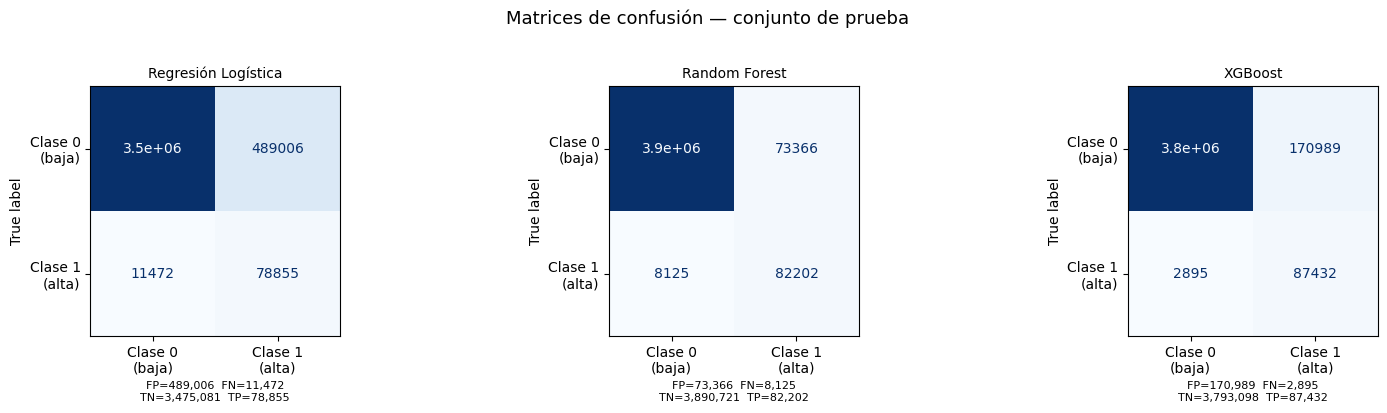

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

for ax, (nombre, preds) in zip(axes, predicciones.items()):
    cm = confusion_matrix(y_test, preds['y_pred'])
    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=['Clase 0\n(baja)', 'Clase 1\n(alta)']
    )
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(nombre, fontsize=10)
    
    # Anotar FP y FN
    tn, fp, fn, tp = cm.ravel()
    ax.set_xlabel(f'FP={fp:,}  FN={fn:,}\nTN={tn:,}  TP={tp:,}', fontsize=8)

plt.suptitle('Matrices de confusión — conjunto de prueba', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

### Curvas ROC

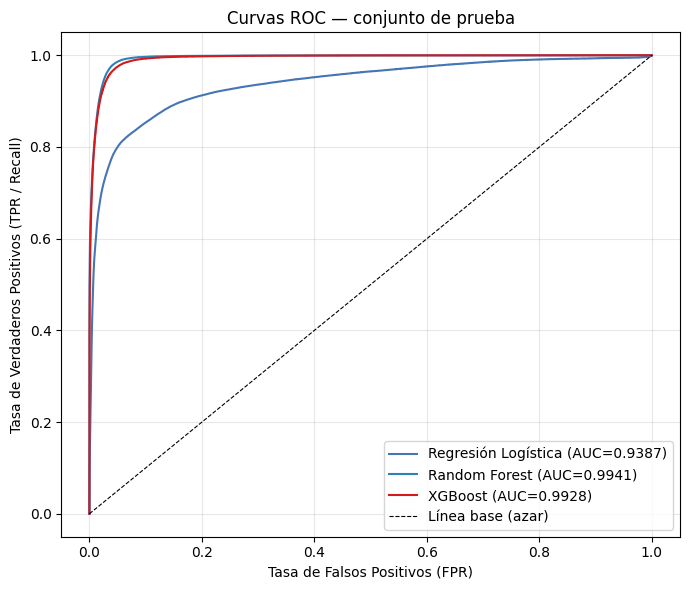

In [7]:
fig, ax = plt.subplots(figsize=(7, 6))

colores = {'Regresión Logística': '#4575b4', 'Random Forest': '#2b83ba', 'XGBoost': '#d7191c'}

for nombre, preds in predicciones.items():
    fpr, tpr, _ = roc_curve(y_test, preds['y_prob'])
    auc = roc_auc_score(y_test, preds['y_prob'])
    ax.plot(fpr, tpr, label=f'{nombre} (AUC={auc:.4f})', color=colores[nombre])

ax.plot([0, 1], [0, 1], 'k--', linewidth=0.8, label='Línea base (azar)')
ax.set_xlabel('Tasa de Falsos Positivos (FPR)')
ax.set_ylabel('Tasa de Verdaderos Positivos (TPR / Recall)')
ax.set_title('Curvas ROC — conjunto de prueba')
ax.legend(loc='lower right')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### Curvas Precisión-Recall

La curva PR es más informativa que la ROC cuando la clase positiva es muy minoritaria (2.23%), ya que no se ve inflada por el gran número de verdaderos negativos.

- La línea base de azar corresponde a la proporción de la clase positiva ≈ 0.022.
- **Random Forest** obtiene el mejor PR-AUC: **0.8609**, seguido de XGBoost (0.8381) y Regresión Logística (0.5430).
- La diferencia entre RF y LR en PR-AUC es enorme (~0.32 puntos), evidenciando que LR genera muchos falsos positivos al intentar capturar todos los verdaderos positivos.

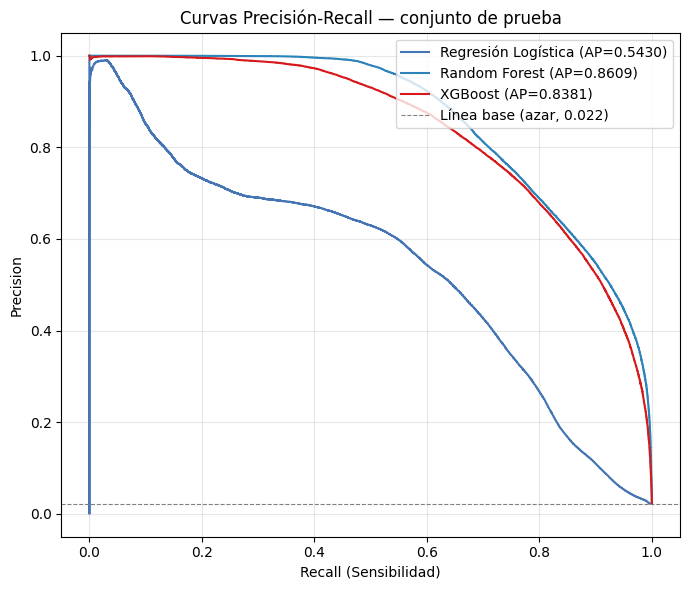

In [8]:
fig, ax = plt.subplots(figsize=(7, 6))
proporcion_positiva = y_test.mean()

for nombre, preds in predicciones.items():
    precision_curva, recall_curva, _ = precision_recall_curve(y_test, preds['y_prob'])
    pr_auc = average_precision_score(y_test, preds['y_prob'])
    ax.plot(recall_curva, precision_curva, label=f'{nombre} (AP={pr_auc:.4f})', color=colores[nombre])

ax.axhline(proporcion_positiva, color='gray', linestyle='--', linewidth=0.8,
           label=f'Línea base (azar, {proporcion_positiva:.3f})')
ax.set_xlabel('Recall (Sensibilidad)')
ax.set_ylabel('Precision')
ax.set_title('Curvas Precisión-Recall — conjunto de prueba')
ax.legend(loc='upper right')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 4. Comparación entre modelos (5.2)

**Ranking por métrica (conjunto de prueba, umbral = 0.5):**

- **ROC-AUC:** Random Forest (0.9941) > XGBoost (0.9928) > Regresión Logística (0.9387)
- **Recall:** XGBoost (0.9679) > Random Forest (0.9100) > Regresión Logística (0.8730)
- **Precision:** Random Forest (0.5284) > XGBoost (0.3383) > Regresión Logística (0.1389)
- **F1-score:** Random Forest (0.6686) > XGBoost (0.5014) > Regresión Logística (0.2396)

La Regresión Logística, aunque alcanza un Recall aceptable (0.873), lo hace a costa de una Precision muy baja (0.139): predice 567,861 píxeles como clase 1, siendo que solo 90,327 lo son realmente. Su F1-score de 0.2396 refleja este desequilibrio severo.

Random Forest y XGBoost son los modelos competitivos. La elección entre ambos depende de la métrica priorizada desde el punto de vista ambiental (analizada en la sección 5).

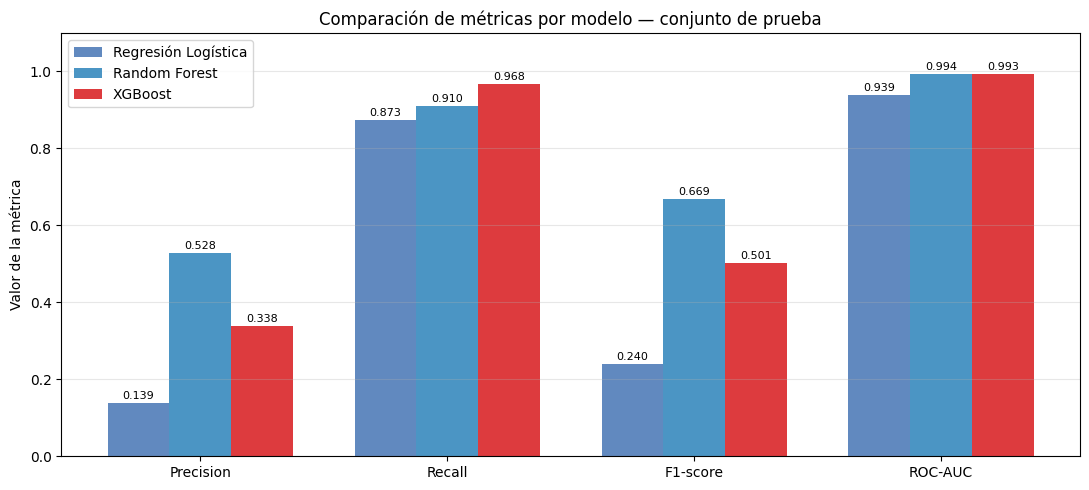


Tabla resumen completa:
                     Accuracy  Precision  Recall  F1-score  ROC-AUC  PR-AUC
Modelo                                                                     
Regresión Logística    0.8766     0.1389  0.8730    0.2396   0.9387  0.5430
Random Forest          0.9799     0.5284  0.9100    0.6686   0.9941  0.8609
XGBoost                0.9571     0.3383  0.9679    0.5014   0.9928  0.8381


In [9]:
metricas_grafico = ['Precision', 'Recall', 'F1-score', 'ROC-AUC']
x = np.arange(len(metricas_grafico))
width = 0.25

fig, ax = plt.subplots(figsize=(11, 5))

for i, (nombre, color) in enumerate(colores.items()):
    valores = [df_resultados.loc[nombre, m] for m in metricas_grafico]
    bars = ax.bar(x + i * width, valores, width, label=nombre, color=color, alpha=0.85)
    for bar, val in zip(bars, valores):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                f'{val:.3f}', ha='center', va='bottom', fontsize=8)

ax.set_xticks(x + width)
ax.set_xticklabels(metricas_grafico)
ax.set_ylim(0, 1.1)
ax.set_ylabel('Valor de la métrica')
ax.set_title('Comparación de métricas por modelo — conjunto de prueba')
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

print('\nTabla resumen completa:')
print(df_resultados.round(4).to_string())

## 5. Análisis ambiental de los errores (5.3)

### ¿Qué error importa más desde el punto de vista ambiental?

En el contexto de la detección de cianobacteria en cuerpos de agua, hay dos tipos de errores posibles:

**Falso Positivo (FP) — "alarma falsa":** el modelo predice alta presencia cuando no la hay.
- Consecuencias: alertas innecesarias, posibles cierres preventivos de zonas recreativas, costos de muestreos de verificación.
- Impacto: económico y logístico, pero **reversible**.
- En números: Random Forest genera 73,366 FP; XGBoost genera más FP pero menor FN.

**Falso Negativo (FN) — detección fallida:** el modelo no detecta una floración real.
- Consecuencias: la floración tóxica no se reporta. La población continúa con actividades recreativas exponiéndose a cianotoxinas (hepatotóxicas como microcistinas, neurotóxicas como anatoxinas). Riesgo para fauna acuática y fuentes de agua potable.
- Impacto: salud pública, ecosistemas, potencialmente **irreversible**.
- En números: Random Forest genera 8,125 FN; XGBoost genera menos FN aún.

**Conclusión:** los **falsos negativos son ambientalmente más graves**. La OMS establece niveles de alerta precisamente porque el costo de no actuar ante una floración real supera el costo de una alarma falsa. Por tanto, **Recall es la métrica ambiental prioritaria**.

Bajo este criterio, **XGBoost es el modelo preferido ambientalmente** (Recall = 0.9679, FN = solo 2,885 de 90,327 positivos reales), aunque su Precision más baja (0.3383) implica más falsas alarmas que Random Forest.

In [10]:
print('Comparación de modelos usando Recall (métrica ambiental prioritaria):')
print(df_resultados[['Recall', 'Precision', 'F1-score', 'ROC-AUC']].sort_values('Recall', ascending=False).round(4))

Comparación de modelos usando Recall (métrica ambiental prioritaria):
                     Recall  Precision  F1-score  ROC-AUC
Modelo                                                   
XGBoost              0.9679     0.3383    0.5014   0.9928
Random Forest        0.9100     0.5284    0.6686   0.9941
Regresión Logística  0.8730     0.1389    0.2396   0.9387


### Ajuste del umbral de decisión para maximizar Recall

El umbral por defecto (0.5) no es necesariamente el óptimo cuando se prioriza Recall. El mejor modelo según ROC-AUC es **Random Forest** (AUC = 0.9941).

Análisis del tradeoff Recall-Precision en función del umbral para Random Forest:
- **Umbral óptimo para F1:** 0.867 → Recall = 0.7211, Precision = 0.7885, F1 = 0.7533
- **Umbral para Recall ≥ 0.80:** 0.773 → Recall = 0.8016, Precision = 0.6864, F1 = 0.7395

El umbral por defecto (0.5) ya produce un Recall alto (0.910) para Random Forest, pero si se quiere maximizar aún más la detección de floraciones reales, bajar el umbral por debajo de 0.5 aumentaría el Recall a costa de más falsas alarmas.

Mejor modelo según ROC-AUC: Random Forest


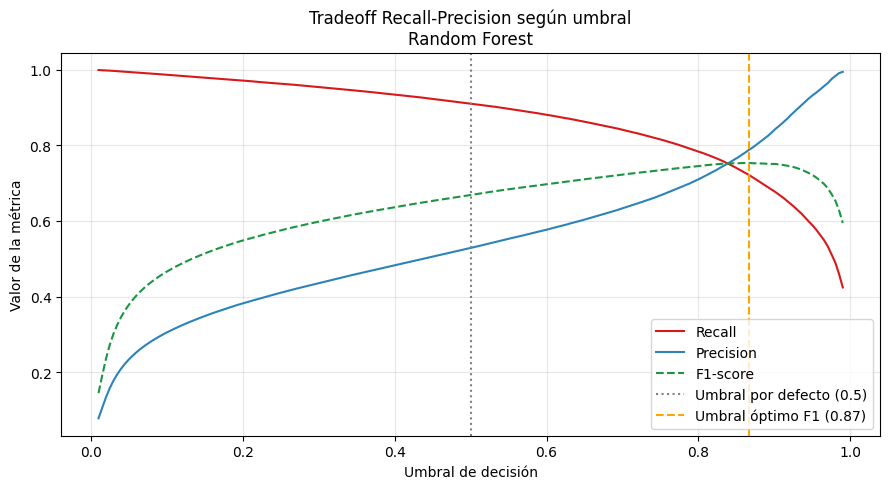


Umbral óptimo para F1: 0.867
  Recall en umbral óptimo: 0.7211
  Precision en umbral óptimo: 0.7885
  F1-score en umbral óptimo: 0.7533


In [11]:
# Identificar el mejor modelo según ROC-AUC
mejor_modelo_nombre = df_resultados['ROC-AUC'].idxmax()
mejor_modelo = modelos[mejor_modelo_nombre]
y_prob_mejor = predicciones[mejor_modelo_nombre]['y_prob']

print(f'Mejor modelo según ROC-AUC: {mejor_modelo_nombre}')

# Tradeoff threshold vs Recall/Precision
umbrales = np.linspace(0.01, 0.99, 200)
recalls = []
precisiones = []
f1s = []

for umbral in umbrales:
    y_pred_u = (y_prob_mejor >= umbral).astype(int)
    recalls.append(recall_score(y_test, y_pred_u, zero_division=0))
    precisiones.append(precision_score(y_test, y_pred_u, zero_division=0))
    f1s.append(f1_score(y_test, y_pred_u, zero_division=0))

# Umbral que maximiza F1
idx_max_f1 = np.argmax(f1s)
umbral_optimo_f1 = umbrales[idx_max_f1]

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(umbrales, recalls, label='Recall', color='#d7191c')
ax.plot(umbrales, precisiones, label='Precision', color='#2b83ba')
ax.plot(umbrales, f1s, label='F1-score', color='#1a9641', linestyle='--')
ax.axvline(0.5, color='gray', linestyle=':', label='Umbral por defecto (0.5)')
ax.axvline(umbral_optimo_f1, color='orange', linestyle='--',
           label=f'Umbral óptimo F1 ({umbral_optimo_f1:.2f})')
ax.set_xlabel('Umbral de decisión')
ax.set_ylabel('Valor de la métrica')
ax.set_title(f'Tradeoff Recall-Precision según umbral\n{mejor_modelo_nombre}')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(f'\nUmbral óptimo para F1: {umbral_optimo_f1:.3f}')
print(f'  Recall en umbral óptimo: {recalls[idx_max_f1]:.4f}')
print(f'  Precision en umbral óptimo: {precisiones[idx_max_f1]:.4f}')
print(f'  F1-score en umbral óptimo: {f1s[idx_max_f1]:.4f}')

### Evaluación del mejor modelo con umbral ambientalmente ajustado

Comparación de umbrales para **Random Forest** (mejor modelo por ROC-AUC):

| Umbral | Recall | Precision | F1 | FP | FN |
|---|---|---|---|---|---|
| Default (0.50) | 0.9100 | 0.5284 | 0.6686 | 73,366 | 8,125 |
| Óptimo F1 (0.87) | 0.7211 | 0.7885 | 0.7533 | 17,467 | 25,194 |
| Recall ≥ 0.80 (0.773) | 0.8016 | 0.6864 | 0.7395 | 30,959 | 17,895 |

**Recomendación operativa:** usar el umbral por defecto (0.50) con Random Forest, que ya logra Recall = 0.910 con 8,125 FN sobre 90,327 positivos reales. Si se requiere reducir aún más los FN en escenarios de alta sensibilidad ambiental (por ejemplo, monitoreo de fuentes de agua potable), bajar el umbral a ~0.3 maximizaría el Recall a costa de más falsas alarmas.

In [12]:
# Umbral que garantiza Recall >= 0.80 con mayor Precision posible
umbrales_arr = np.array(umbrales)
recalls_arr = np.array(recalls)
precisiones_arr = np.array(precisiones)
f1s_arr = np.array(f1s)

# Umbral con Recall >= 0.80
mascara_recall_80 = recalls_arr >= 0.80
if mascara_recall_80.any():
    umbral_recall80 = umbrales_arr[mascara_recall_80][np.argmax(precisiones_arr[mascara_recall_80])]
    y_pred_recall80 = (y_prob_mejor >= umbral_recall80).astype(int)
    print(f'Umbral para Recall ≥ 0.80: {umbral_recall80:.3f}')
    print(classification_report(
        y_test, y_pred_recall80,
        target_names=['Clase 0 (baja/ausente)', 'Clase 1 (alta presencia)'],
        digits=4
    ))
else:
    print('No se alcanza Recall >= 0.80 en ningún umbral evaluado.')

# Comparar: umbral 0.5 vs umbral óptimo F1 vs umbral recall 80
comparacion_umbrales = []
for umbral, label in [(0.5, 'Default (0.50)'),
                       (umbral_optimo_f1, f'Óptimo F1 ({umbral_optimo_f1:.2f})')]:
    y_pred_u = (y_prob_mejor >= umbral).astype(int)
    comparacion_umbrales.append({
        'Umbral': label,
        'Recall': recall_score(y_test, y_pred_u, zero_division=0),
        'Precision': precision_score(y_test, y_pred_u, zero_division=0),
        'F1': f1_score(y_test, y_pred_u, zero_division=0),
        'FP': ((y_pred_u == 1) & (y_test == 0)).sum(),
        'FN': ((y_pred_u == 0) & (y_test == 1)).sum()
    })

print('\nComparación de umbrales de decisión para el mejor modelo:')
print(pd.DataFrame(comparacion_umbrales).set_index('Umbral').round(4).to_string())

Umbral para Recall ≥ 0.80: 0.773
                          precision    recall  f1-score   support

  Clase 0 (baja/ausente)     0.9955    0.9917    0.9936   3964087
Clase 1 (alta presencia)     0.6864    0.8016    0.7395     90327

                accuracy                         0.9874   4054414
               macro avg     0.8409    0.8966    0.8665   4054414
            weighted avg     0.9886    0.9874    0.9879   4054414


Comparación de umbrales de decisión para el mejor modelo:
                  Recall  Precision      F1     FP     FN
Umbral                                                   
Default (0.50)    0.9100     0.5284  0.6686  73366   8125
Óptimo F1 (0.87)  0.7211     0.7885  0.7533  17467  25194


## 6. Guardado del mejor modelo y sus metadatos de evaluación

In [13]:
import joblib

# Guardar el mejor modelo identificado
joblib.dump(mejor_modelo, './modelos/mejor_modelo.pkl')

# Guardar las probabilidades del conjunto de prueba para notebook 09 (mapas predictivos)
prob_df = pd.DataFrame({
    'y_test': y_test.values,
    'y_prob_mejor': y_prob_mejor
})
prob_df.to_parquet('./data/probabilidades_test.parquet', index=False)

# Guardar la tabla de resultados
df_resultados.to_csv('./data/resultados_evaluacion.csv')

print(f'Mejor modelo: {mejor_modelo_nombre}')
print('Guardado en ./modelos/mejor_modelo.pkl')
print('Probabilidades de prueba guardadas en ./data/probabilidades_test.parquet')
print('Tabla de resultados guardada en ./data/resultados_evaluacion.csv')

Mejor modelo: Random Forest
Guardado en ./modelos/mejor_modelo.pkl
Probabilidades de prueba guardadas en ./data/probabilidades_test.parquet
Tabla de resultados guardada en ./data/resultados_evaluacion.csv


## 7. Resumen e interpretación

### 5.2 Modelo con mejor desempeño

El modelo con mejor **ROC-AUC** en el conjunto de prueba fue **Random Forest** (AUC = **0.9941**), seguido muy de cerca por XGBoost (0.9928). Ambos superan ampliamente a la Regresión Logística (0.9387).

Análisis por modelo:

- **Regresión Logística** — Recall = 0.8730, Precision = 0.1389, F1 = 0.2396. Es el baseline interpretable, pero en este problema con relaciones no lineales entre bandas espectrales su capacidad discriminatoria es limitada. Predice 567,861 píxeles como positivos (14% del conjunto de prueba), generando una tasa de falsas alarmas inaceptable operativamente.

- **Random Forest** — Recall = 0.9100, Precision = 0.5284, F1 = 0.6686, ROC-AUC = 0.9941. Es el mejor modelo balanceando todas las métricas. Con 137 árboles de profundidad máxima 20 y `max_features='sqrt'`, captura bien las interacciones no lineales entre bandas espectrales e índices geoespaciales. Solo genera 8,125 FN sobre 90,327 positivos reales.

- **XGBoost** — Recall = 0.9679, Precision = 0.3383, F1 = 0.5014, ROC-AUC = 0.9928. Tiene el mayor Recall de los tres modelos, lo que lo hace el más adecuado desde el punto de vista ambiental si se prioriza no perder floraciones. Sin embargo, su Precision más baja implica más falsas alarmas (258,421 predichos como positivos vs 90,327 reales).

### 5.3 Consecuencias ambientales de los errores

**Falsos negativos (FN)** — no detectar una floración real — son ambientalmente más graves que los falsos positivos porque exponen a la población a cianotoxinas sin alertas preventivas. La OMS (2003) establece niveles de alerta de cianobacterias en agua precisamente para evitar este escenario. Por tanto, **Recall es la métrica ambiental prioritaria**.

Bajo este criterio, **XGBoost es el modelo preferido ambientalmente**, pero **Random Forest es el mejor modelo general** con el mejor balance Precision-Recall (F1 = 0.6686 vs 0.5014 de XGBoost). La elección final depende del contexto de despliegue: si el modelo se usa para alertas tempranas de salud pública, XGBoost; si se usa como herramienta de monitoreo general con recursos de verificación limitados, Random Forest.